In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import math

In [6]:
batch_size = 8
seq_len = 128
embed_dim = 768
num_heads = 12
head_dim = embed_dim // num_heads

x = torch.randn(batch_size, seq_len, embed_dim)
print(f"Input tensor :{x.shape}")

x_heads = x.view(batch_size, seq_len, num_heads, head_dim)
print(f"splitting the tensor heads: {x_heads.shape}")

x_ready = x_heads.permute(0, 2, 1, 3)
print(f"permutting for attention: {x_ready.shape}")

Input tensor :torch.Size([8, 128, 768])
splitting the tensor heads: torch.Size([8, 128, 12, 64])
permutting for attention: torch.Size([8, 12, 128, 64])


In [13]:
v = torch.tensor([1., 0.])

rotate_90 = torch.tensor([
    [0., -1.], 
    [1., 0.]
])

rotated_90 = rotate_90 @ v
print(f"rotated by 90 deg: {rotated_90.tolist()}")

angle = math.radians(45)
rotate_45 = torch.tensor([
    [math.cos(angle), -math.sin(angle)], 
    [math.sin(angle), -math.cos(angle)]
])

rotated_45 = rotate_45 @ v
print(f"rotated by 45 deg: [{rotated_45[0]:.3f}, {rotated_45[1]:.3f}]")

rotated by 90 deg: [0.0, 1.0]
rotated by 45 deg: [0.707, 0.707]


In [14]:
def plot_transformation(matrix, title="Transformation"):
    """Visualize how a 2x2 matrix transforms a grid of points."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Create a grid of points
    n = 10
    x = np.linspace(-2, 2, n)
    y = np.linspace(-2, 2, n)

    # Plot original grid
    ax = axes[0]
    ax.set_title("Original", fontsize=14, fontweight='bold')
    for xi in x:
        ax.plot([xi]*n, y, 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        ax.plot(x, [yi]*n, 'b-', alpha=0.3, linewidth=1)

    # Highlight a square
    square_x = [0, 1, 1, 0, 0]
    square_y = [0, 0, 1, 1, 0]
    ax.plot(square_x, square_y, 'r-', linewidth=3)

    # Arrow for basis vectors
    ax.annotate('', xy=(1, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=(0, 1), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # Plot transformed grid
    M = np.array(matrix)
    ax = axes[1]
    ax.set_title(f"{title}", fontsize=14, fontweight='bold')

    for xi in x:
        points = np.array([[xi, yi] for yi in y])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        points = np.array([[xi, yi] for xi in x])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)

    # Transform the square
    sq = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
    sq_t = M @ sq
    ax.plot(sq_t[0], sq_t[1], 'r-', linewidth=3)

    # Transform basis vectors
    e1_t = M @ np.array([1, 0])
    e2_t = M @ np.array([0, 1])
    ax.annotate('', xy=e1_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=e2_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    plt.tight_layout()
    plt.show()

print("✅ Visualization function ready! Run the cells below.")

✅ Visualization function ready! Run the cells below.


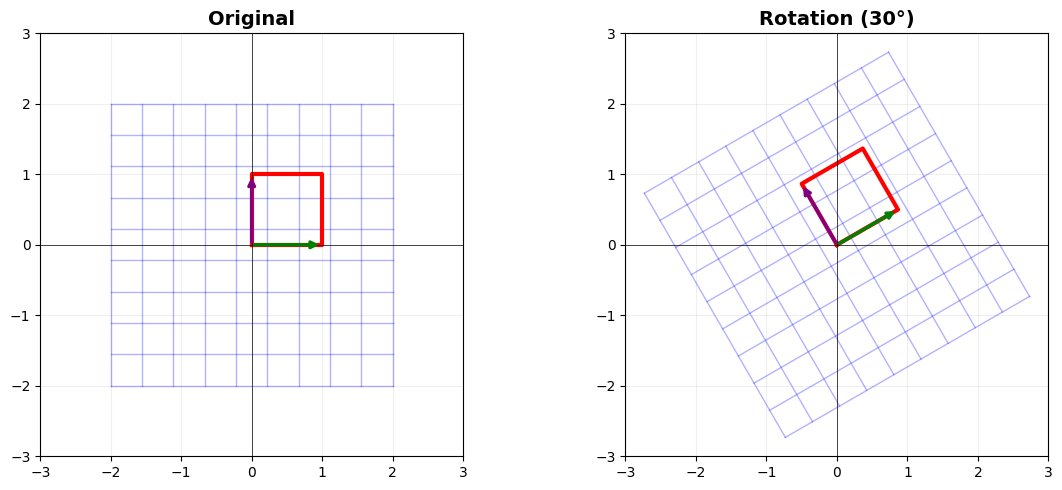

In [15]:
# 🔥 ROTATION — the grid spins!
angle = math.radians(30)
rotation = [[math.cos(angle), -math.sin(angle)],
            [math.sin(angle),  math.cos(angle)]]
plot_transformation(rotation, "Rotation (30°)")